In [1]:
import pandas as pd
import numpy as np

In [ ]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False)

In [5]:
X, y = mnist["data"], mnist["target"]

In [ ]:
display(X.shape)
display(y) #Array de uma dimensão

(70000, 784)

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

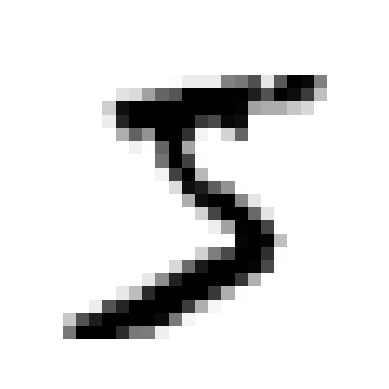

In [27]:
import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [28]:
y[0]

'5'

In [22]:
x_train, x_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]
x_train

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=int64)

In [26]:
y_train_5 = (y_train == '5') #True para todos os 5s, False para os outros dígitos
y_test_5 = (y_test == '5')


from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(x_train, y_train_5)

SGDClassifier(random_state=42)

In [32]:
sgd_clf.predict([some_digit])

array([ True])

In [33]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, x_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

### Testando a classificação com um modelo burro
##### E ainda assim tendo uma acuracia alta

In [ ]:
from sklearn.base import BaseEstimator
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(x_train, y_train_5)
print(any(dummy_clf.predict(x_train))) #O DummyClassifier sempre prevê a classe mais frequente, que é "não 5" (False), então ele nunca prevê "5" (True). Portanto, a função any() retorna False, indicando que não há previsões de "5" (True) no conjunto de treinamento.

cross_val_score(dummy_clf, x_train, y_train_5, cv=3, scoring="accuracy")

False


array([0.90965, 0.90965, 0.90965])

In [43]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3) # Faz validação cruzada e retorna as previsões para cada instância do conjunto de treinamento
y_train_pred

array([ True, False, False, ...,  True, False, False])

In [45]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]], dtype=int64)

In [46]:
# Com a matriz de confusão podemos calcular a precisão, recall e F1-score:
# precisao = TP / (TP + FP)
# recall = TP / (TP + FN)
# f1_score = 2 * (precisao * recall) / (precisao;

from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_train_5, y_train_pred)
recall = recall_score(y_train_5, y_train_pred)

f1 = f1_score(y_train_5, y_train_pred)

In [ ]:
print("Precisão:", precision)
print("Recall:", recall)
print("F1-score:", f1)

# Exemplo de uso de precisão: Videos seguros para crianças
# Exemplo de uso de recall: Detecção de fraudes em transações financeiras

Precisão: 0.8370879772350012
Recall: 0.6511713705958311
F1-score: 0.7325171197343847


In [50]:
y_scores = cross_val_predict(sgd_clf, x_train, y_train_5, cv=3, method="decision_function") # Retorna os scores de decisão para cada instância do conjunto de treinamento

from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

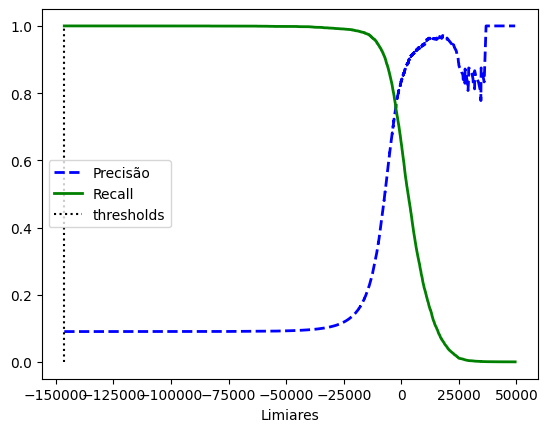

In [59]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precisão", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(thresholds[0], 0, 1.0, "k", "dotted", label="thresholds")
plt.xlabel("Limiares")
plt.legend(loc="center left")
plt.show()

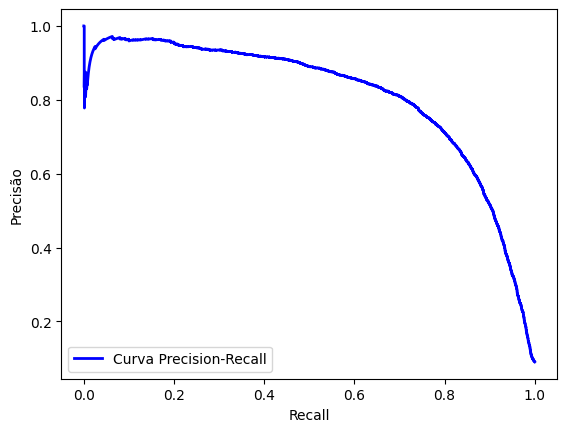

In [64]:
plt.plot(recalls, precisions, "b-", linewidth=2, label="Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precisão")
plt.legend(loc="lower left")
plt.show()

In [66]:
idx_for_90_precision = (precisions >= 0.90).argmax() # Encontra o índice do primeiro limiar onde a precisão é maior ou igual a 90%
thresholds_for_90_precision = thresholds[idx_for_90_precision]
thresholds_for_90_precision

IndexError: index 57109 is out of bounds for axis 0 with size 3908

In [ ]:
# curva  ROC é semelhante a curva de Precisão/Revocação mas é usada para avaliar classificadores binários em vez de multiclasse. A curva ROC plota a taxa de verdadeiros positivos (TPR) contra a taxa de falsos positivos (FPR) para diferentes limiares de classificação. O objetivo é maximizar a TPR enquanto minimiza a FPR, o que indica um bom desempenho do classificador.

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

idx_for_threshold_at_90 = (threshold <= thresholds_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]